In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('ticks',
              rc={'axes.facecolor': (0, 0, 0, 0)})
sns.set_context('talk')

from matplotlib import rcParams
rcParams['font.family'] = 'sans-serif'
rcParams['figure.dpi'] = 150

In [2]:
import os
import warnings
import itertools
import numpy as np
import pandas as pd

In [3]:
def read_chibio(file_name, emissions=None, overlay=False):
    m = pd.read_csv(file_name)
    
    if emissions is None:
        emissions = [x for x in m.columns
                     if x.startswith('FP')
                     and not x.endswith('base')]

    # get time in hours
    m['time'] = m['exp_time'] / 60 / 60
    # get log of the OD
    m['ln(od)'] = np.log(m['od_measured'])

    # create a timedelta index
    m.index = pd.to_timedelta(m['time'], unit='h')
    # smooth OD readings taking the median over a sliding 10-minute window
    m['smooth_od'] = m.rolling('60min', min_periods=5)['od_measured'].median()
    # smooth emission readings taking the median over a sliding 10-minute window
    
    # silence warnings in the following loops
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', category=pd.errors.PerformanceWarning)
        for em in emissions:
            m[f'smooth_{em}'] = m.rolling('60min', min_periods=5)[em].median()
            m[f'smooth_norm_{em}'] = m[f'smooth_{em}'] / m['smooth_od']
            m[f'norm_{em}'] = m[em] / (m['od_measured'] + 1)
    
        for em1, em2 in itertools.combinations(emissions, 2):
            m[f'{em1}_{em2}_ratio'] = m[em1] / m[em2]
            m[f'smooth_{em1}_{em2}_ratio'] = m[f'smooth_{em1}'] / m[f'smooth_{em2}']
            m[f'norm_{em1}_{em2}_ratio'] = m[f'{em1}_{em2}_ratio'] / (m['od_measured'] + 1)
            m[f'{em1}_{em2}_proportion'] = m[em1] / (m[em1] + m[em2])
            m[f'smooth_{em1}_{em2}_proportion'] = m[f'smooth_{em1}'] / (m[f'smooth_{em1}'] + m[f'smooth_{em2}'])
            m[f'norm_{em1}_{em2}_proportion'] = m[f'{em1}_{em2}_proportion'] / (m['od_measured'] + 1)
        for em2, em1 in itertools.combinations(emissions, 2):
            m[f'{em1}_{em2}_ratio'] = m[em1] / m[em2]
            m[f'smooth_{em1}_{em2}_ratio'] = m[f'smooth_{em1}'] / m[f'smooth_{em2}']
            m[f'norm_{em1}_{em2}_ratio'] = m[f'{em1}_{em2}_ratio'] / (m['od_measured'] + 1)
            m[f'{em1}_{em2}_proportion'] = m[em1] / (m[em1] + m[em2])
            m[f'smooth_{em1}_{em2}_proportion'] = m[f'smooth_{em1}'] / (m[f'smooth_{em1}'] + m[f'smooth_{em2}'])
            m[f'norm_{em1}_{em2}_proportion'] = m[f'{em1}_{em2}_proportion'] / (m['od_measured'] + 1)
    
    return m

In [4]:
from matplotlib.offsetbox import TextArea, HPacker, AnnotationBbox

def apply_rich_labels(ax):
    # 1. Force a draw to ensure we can read properties
    ax.figure.canvas.draw()
    
    sample_label = ax.get_yticklabels()[0]
    font_size = sample_label.get_fontsize()
    font_family = sample_label.get_fontfamily()
    
    # Increase pad to 8 to move text away from the tick marks
    tick_pad = 10

    style_map = {
        'PL': 'xkcd:teal', 
        'PM': 'xkcd:salmon', 
        'LM': 'xkcd:dark grey', 
    }

    ticks = ax.get_yticks()
    labels = [l.get_text() for l in ax.get_yticklabels()]

    # Clear original labels
    ax.set_yticklabels([])

    for y_val, text in zip(ticks, labels):
        if not text: continue
        
        children = []
        # Chunk logic
        chunks = [text[i:i+2] for i in range(0, len(text), 2)]
        
        for chunk in chunks:
            color = style_map.get(chunk.upper(), 'black')
            ta = TextArea(chunk, textprops={
                'color': color, 
                'size': font_size,
                'family': font_family,
                'weight': 'bold' if chunk in style_map else 'normal'
            })
            children.append(ta)

        # Added sep=3 to create space between the chunks
        hbox = HPacker(children=children, align="baseline", pad=0, sep=0)
        
        ab = AnnotationBbox(hbox, (0, y_val),
                            xybox=(-tick_pad, 0),
                            xycoords=ax.get_yaxis_transform(),
                            boxcoords="offset points",
                            box_alignment=(1, 0.5), 
                            frameon=False)
        ax.add_artist(ab)

In [5]:
d = {(0, 0.1): ('M9', 'white'),
     (0.1, 0.21): ('PL', 'xkcd:teal'),
     (0.21, 0.32): ('PM', 'xkcd:salmon'),
     (0.32, 0.44): ('LM', 'xkcd:dark grey'),
     (1.1, 1.2): ('PLpmlm', '#249186'),
     (0.99, 1.1): ('plPMlm', '#c5625b'),
     (0.88, 0.99): ('plpmLM', '#b1b2b1'),     
     (0.77, 0.88): ('PLPMlm', '#71776e'),     
     (0.66, 0.77): ('PLpmLM', '#66a59e'),
     (0.55, 0.66): ('plPMLM', '#c28a86'),
     (0.44, 0.55): ('PLPMLM', '#898d86'),
     }
colors = {'M9': 'white',
          'PL': 'xkcd:teal',
          'PM': 'xkcd:pale red',
          'LM': 'grey',
          'PLPMLM': '#898d86',
          'plPMLM': '#c28a86',
          'PLpmLM': '#66a59e',
          'PLPMlm': '#71776e',
          'plpmLM': '#b1b2b1',
          'plPMlm': '#c5625b',
          'PLpmlm': '#249186'}

## Chi.bio

In [6]:
m = read_chibio('2024-06-19 18_42_54_M7_data.csv')

In [7]:
# remove last time point
m = m[m['time'] < 1.2]

In [8]:
cols = ['time',
        'od_measured', 'ln(od)',
        'FP1_emit1', 'FP2_emit1',
        'norm_FP1_emit1', 'norm_FP2_emit1',
        'FP1_emit1_FP2_emit1_ratio',
        'norm_FP1_emit1_FP2_emit1_ratio',
        'FP1_emit1_FP2_emit1_proportion',
        'norm_FP1_emit1_FP2_emit1_proportion',
        'FP2_emit1_FP1_emit1_proportion',
        'norm_FP2_emit1_FP1_emit1_proportion',]

In [9]:
res = []
for (x, y), (label, color) in d.items():
    for idx, row in m[(m['time'] >= x) & (m['time'] <= y)].iterrows():
        values = [row[col] for col in cols]
        res.append([label, color] + values)
n = pd.DataFrame(res,
                 columns=['label', 'color'] + cols)
n.to_csv('calibration.tsv', sep='\t', index=False)

/home/galmar/.local/share/pipx/venvs/jupyterlab/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 50.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/galmar/.local/share/pipx/venvs/jupyterlab/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 57.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/galmar/.local/share/pipx/venvs/jupyterlab/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 14.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/galmar/.local/share/pipx/venvs/jupyterlab/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 28.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  

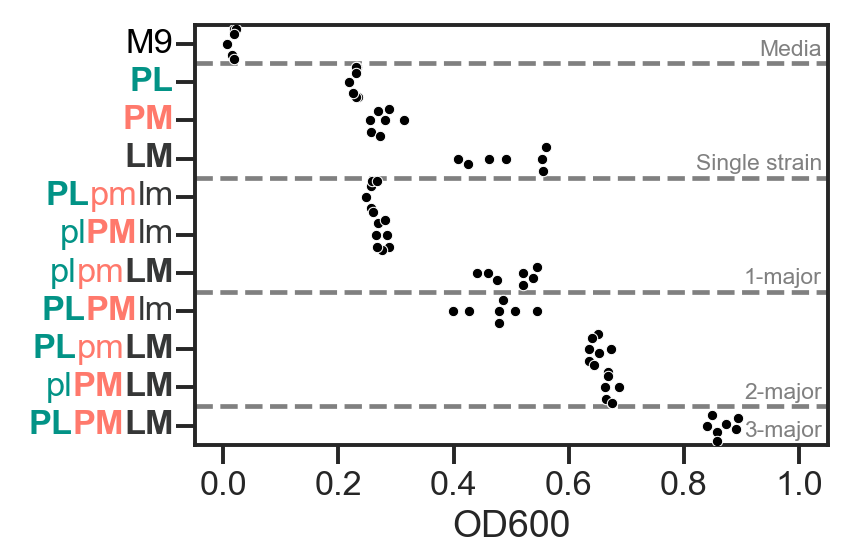

In [10]:
section_labels = {1: 'Media',
                  4: 'Single strain',
                  7: '1-major',
                  10: '2-major'}

with warnings.catch_warnings():
    warnings.simplefilter('ignore', category=UserWarning)
    cp = sns.catplot(data=n,
                     y='label', x='od_measured',
                     height=4, aspect=1.5,
                     color='k',
                     linewidth=0.5,
                     edgecolor='w',
                     kind='swarm')
    plt.ylabel('')
    plt.xlabel('OD600')
    sns.despine(right=False, top=False)
    for i, ((x, y), (label, color)) in enumerate(d.items()):
        if i in (1, 4, 7, 10):
            plt.axhline(i - 0.5,
                        color='grey', ls='dashed',
                        zorder=-1)
            plt.text(1.04, i - 0.6, section_labels[i],
                     va='bottom', ha='right',
                     fontsize=11, color='grey', transform=plt.gca().transData)
        # plt.axhspan(ymin=i - 0.5, ymax=i + 0.5,
        #              color=color,
        #              zorder=-1)

    plt.xlim(-0.05, 1.05)
    plt.text(1.04, 11 - 0.6, '3-major',
             va='bottom', ha='right',
             fontsize=11, color='grey', transform=plt.gca().transData)
    
    ax = plt.gca()
    apply_rich_labels(ax)
    # plt.draw()
    # plt.show()

plt.savefig('calibration_OD.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True
           )
plt.savefig('calibration_OD.svg',
            dpi=300, bbox_inches='tight',
            transparent=True);

/home/galmar/.local/share/pipx/venvs/jupyterlab/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 50.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/galmar/.local/share/pipx/venvs/jupyterlab/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 57.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


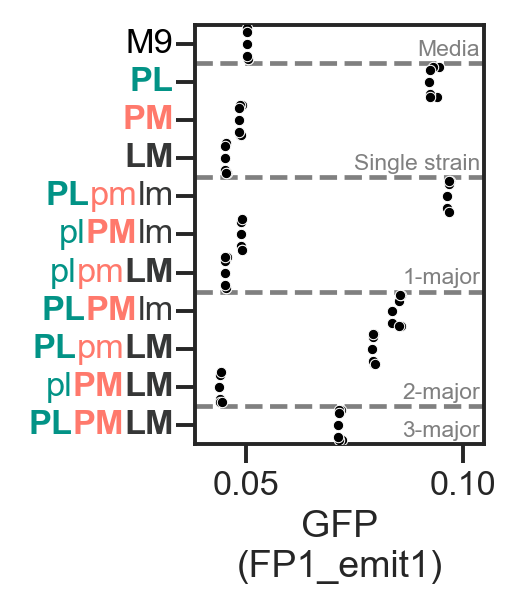

In [11]:
section_labels = {1: 'Media',
                  4: 'Single strain',
                  7: '1-major',
                  10: '2-major'}

with warnings.catch_warnings():
    warnings.simplefilter('ignore', category=UserWarning)
    cp = sns.catplot(data=n,
                     y='label', x='FP1_emit1',
                     height=4, aspect=0.93,
                     color='k',
                     linewidth=0.5,
                     edgecolor='w',
                     kind='swarm')
    plt.ylabel('')
    plt.xlabel('GFP\n(FP1_emit1)')
    sns.despine(right=False, top=False)
    for i, ((x, y), (label, color)) in enumerate(d.items()):
        if i in (1, 4, 7, 10):
            plt.axhline(i - 0.5,
                        color='grey', ls='dashed',
                        zorder=-1)
            plt.text(0.104, i - 0.6, section_labels[i],
                     va='bottom', ha='right',
                     fontsize=11, color='grey', transform=plt.gca().transData)
        # plt.axhspan(ymin=i - 0.5, ymax=i + 0.5,
        #              color=color,
        #              zorder=-1)

    plt.xlim(0.038, 0.105)
    plt.text(0.104, 11 - 0.6, '3-major',
             va='bottom', ha='right',
             fontsize=11, color='grey', transform=plt.gca().transData)
    
    ax = plt.gca()
    apply_rich_labels(ax)
    # plt.draw()
    # plt.show()

plt.savefig('calibration_FP1.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True
           )
plt.savefig('calibration_FP1.svg',
            dpi=300, bbox_inches='tight',
            transparent=True);

/home/galmar/.local/share/pipx/venvs/jupyterlab/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 50.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/galmar/.local/share/pipx/venvs/jupyterlab/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 57.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


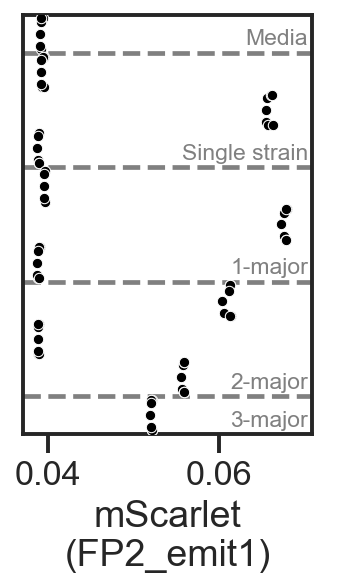

In [12]:
section_labels = {1: 'Media',
                  4: 'Single strain',
                  7: '1-major',
                  10: '2-major'}

with warnings.catch_warnings():
    warnings.simplefilter('ignore', category=UserWarning)
    cp = sns.catplot(data=n,
                     y='label', x='FP2_emit1',
                     height=4, aspect=0.93,
                     color='k',
                     linewidth=0.5,
                     edgecolor='w',
                     kind='swarm')
    plt.ylabel('')
    plt.xlabel('mScarlet\n(FP2_emit1)')
    sns.despine(right=False, top=False)
    for i, ((x, y), (label, color)) in enumerate(d.items()):
        if i in (1, 4, 7, 10):
            plt.axhline(i - 0.5,
                        color='grey', ls='dashed',
                        zorder=-1)
            plt.text(0.0705, i - 0.6, section_labels[i],
                     va='bottom', ha='right',
                     fontsize=11, color='grey', transform=plt.gca().transData)
        # plt.axhspan(ymin=i - 0.5, ymax=i + 0.5,
        #              color=color,
        #              zorder=-1)

    plt.xlim(0.037, 0.071)
    plt.text(0.0705, 11 - 0.6, '3-major',
             va='bottom', ha='right',
             fontsize=11, color='grey', transform=plt.gca().transData)
    
    plt.yticks([])
    # ax = plt.gca()
    # apply_rich_labels(ax)
    # plt.draw()
    # plt.show()

plt.savefig('calibration_FP2.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True
           )
plt.savefig('calibration_FP2.svg',
            dpi=300, bbox_inches='tight',
            transparent=True);

/home/galmar/.local/share/pipx/venvs/jupyterlab/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 50.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/galmar/.local/share/pipx/venvs/jupyterlab/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 14.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/galmar/.local/share/pipx/venvs/jupyterlab/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 42.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/galmar/.local/share/pipx/venvs/jupyterlab/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 57.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  

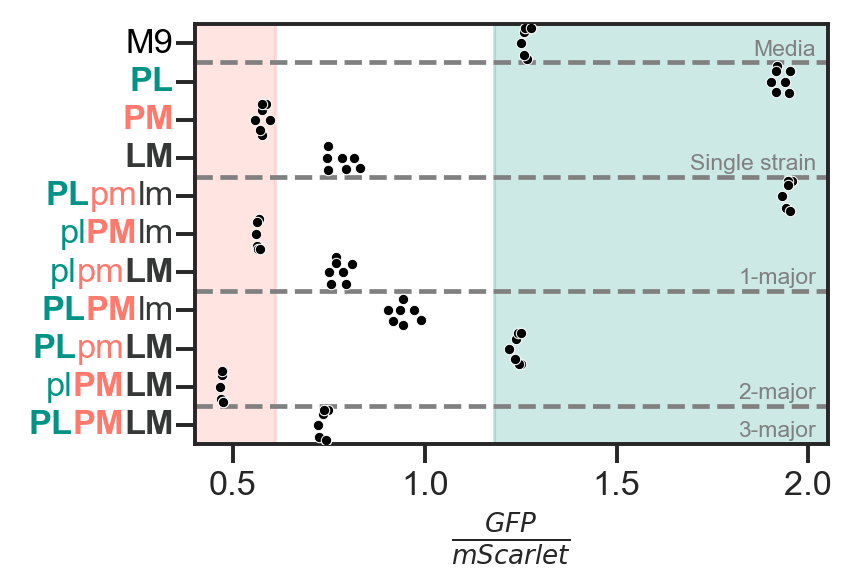

In [13]:
section_labels = {1: 'Media',
                  4: 'Single strain',
                  7: '1-major',
                  10: '2-major'}

with warnings.catch_warnings():
    warnings.simplefilter('ignore', category=UserWarning)
    cp = sns.catplot(data=n,
                     y='label', x='norm_FP1_emit1_FP2_emit1_ratio',
                     height=4, aspect=1.5,
                     color='k',
                     linewidth=0.5,
                     edgecolor='w',
                     kind='swarm')
    plt.ylabel('')
    plt.xlabel(r'$\frac{GFP}{mScarlet}$')
    # plt.fill_between([0.7, 1], [-1, -1], [12, 12],
    #                  color='xkcd:light grey',
    #                  zorder=-1)
    plt.fill_between([0.3, 0.61], [-1, -1], [12, 12],
                     color='xkcd:salmon',
                     alpha=0.2,
                     zorder=-1)
    plt.fill_between([1.18, 3], [-1, -1], [12, 12],
                     color='xkcd:teal',
                     alpha=0.2,
                     zorder=-1)
    # plt.xscale('log')
    sns.despine(right=False, top=False)
    for i, ((x, y), (label, color)) in enumerate(d.items()):
        if i in (1, 4, 7, 10):
            plt.axhline(i - 0.5,
                        color='grey', ls='dashed',
                        zorder=-1)
            plt.text(2.02, i - 0.6, section_labels[i],
                     va='bottom', ha='right',
                     fontsize=11, color='grey', transform=plt.gca().transData)
        # plt.axhspan(ymin=i - 0.5, ymax=i + 0.5,
        #              color=color,
        #              zorder=-1)

    plt.xlim(0.4, 2.05)
    plt.ylim(11-0.5, -0.5)
    plt.text(2.02, 11 - 0.6, '3-major',
             va='bottom', ha='right',
             fontsize=11, color='grey', transform=plt.gca().transData)
    
    ax = plt.gca()
    apply_rich_labels(ax)
    # plt.draw()
    # plt.show()

plt.savefig('calibration_FP1_FP2.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True
           )
plt.savefig('calibration_FP1_FP2.svg',
            dpi=300, bbox_inches='tight',
            transparent=True);

/home/galmar/.local/share/pipx/venvs/jupyterlab/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 50.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/galmar/.local/share/pipx/venvs/jupyterlab/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 42.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/galmar/.local/share/pipx/venvs/jupyterlab/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 57.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


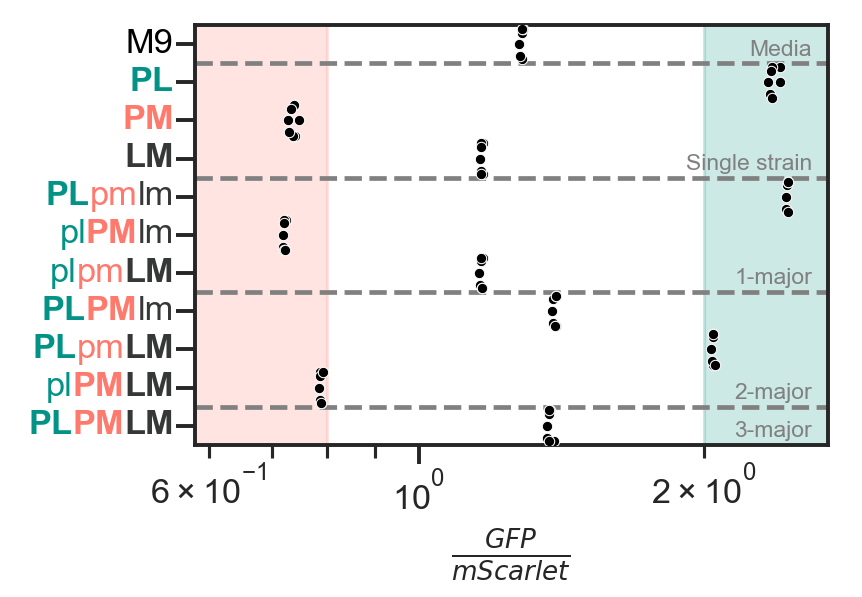

In [14]:
section_labels = {1: 'Media',
                  4: 'Single strain',
                  7: '1-major',
                  10: '2-major'}

with warnings.catch_warnings():
    warnings.simplefilter('ignore', category=UserWarning)
    cp = sns.catplot(data=n,
                     y='label', x='FP1_emit1_FP2_emit1_ratio',
                     height=4, aspect=1.5,
                     color='k',
                     linewidth=0.5,
                     edgecolor='w',
                     kind='swarm')
    plt.ylabel('')
    plt.xlabel(r'$\frac{GFP}{mScarlet}$')
    # plt.fill_between([0.7, 1], [-1, -1], [12, 12],
    #                  color='xkcd:light grey',
    #                  zorder=-1)
    plt.fill_between([0.08, 0.8], [-1, -1], [12, 12],
                     color='xkcd:salmon',
                     alpha=0.2,
                     zorder=-1)
    plt.fill_between([2, 12], [-1, -1], [12, 12],
                     color='xkcd:teal',
                     alpha=0.2,
                     zorder=-1)
    # plt.xscale('log')
    sns.despine(right=False, top=False)
    for i, ((x, y), (label, color)) in enumerate(d.items()):
        if i in (1, 4, 7, 10):
            plt.axhline(i - 0.5,
                        color='grey', ls='dashed',
                        zorder=-1)
            plt.text(2.6, i - 0.6, section_labels[i],
                     va='bottom', ha='right',
                     fontsize=11, color='grey', transform=plt.gca().transData)
        # plt.axhspan(ymin=i - 0.5, ymax=i + 0.5,
        #              color=color,
        #              zorder=-1)

    plt.xlim(0.58, 2.7)
    plt.xscale('log')
    plt.ylim(11-0.5, -0.5)
    plt.text(2.6, 11 - 0.6, '3-major',
             va='bottom', ha='right',
             fontsize=11, color='grey', transform=plt.gca().transData)
    
    ax = plt.gca()
    apply_rich_labels(ax)
    # plt.draw()
    # plt.show()

plt.savefig('calibration_FP1_FP2_raw.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True
           )
plt.savefig('calibration_FP1_FP2_raw.svg',
            dpi=300, bbox_inches='tight',
            transparent=True);

## Plate counts

In [15]:
c = pd.read_excel('counts.xlsx')

In [16]:
c = c.set_index(['label', 'replicate']).stack().reset_index().rename(columns={
    'level_2': 'strain',
    0: 'CFU/mL raw'
})

In [17]:
c['CFU/mL'] = c['CFU/mL raw'] + 50

In [18]:
p = c.groupby(['label', 'replicate']).apply(
              lambda x: x[x['strain'] == 'PL']['CFU/mL'].values[0] /
                        x[x['strain'] == 'PM']['CFU/mL'].values[0],
              include_groups=False).reset_index().rename(columns={0: 'PL / PM'})

In [19]:
pn = c.groupby(['label', 'replicate']).apply(
               lambda x: (x[x['strain'] == 'PL']['CFU/mL raw'].values[0] /
                          x[x['strain'] == 'PM']['CFU/mL raw'].values[0]) /
                         x['CFU/mL'].sum(),
               include_groups=False).reset_index().rename(columns={0: 'PL / PM'})

/tmp/ipykernel_944695/3058127891.py:2: RuntimeWarning: invalid value encountered in scalar divide
  lambda x: (x[x['strain'] == 'PL']['CFU/mL raw'].values[0] /
/tmp/ipykernel_944695/3058127891.py:2: RuntimeWarning: divide by zero encountered in scalar divide
  lambda x: (x[x['strain'] == 'PL']['CFU/mL raw'].values[0] /


/home/galmar/.local/share/pipx/venvs/jupyterlab/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 16.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


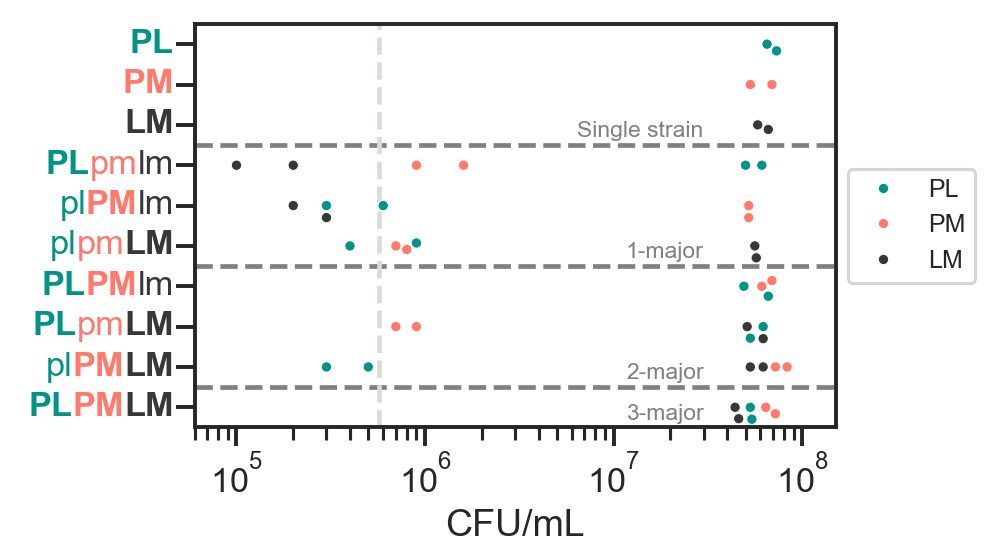

In [20]:
section_labels = {3: 'Single strain',
                  6: '1-major',
                  9: '2-major'}

dd = {k: v for k, v in d.items() if v[0] != 'M9'}

with warnings.catch_warnings():
    warnings.simplefilter('ignore', category=UserWarning)
    cp = sns.catplot(data=c,
                     x='CFU/mL',
                     y='label',
                     hue='strain',
                     palette=['xkcd:teal',
                              'xkcd:salmon',
                              'xkcd:dark grey'],
                     hue_order=['PL', 'PM', 'LM'],
                     order=[x[0] for x in dd.values()],
                     height=4, aspect=1.5,
                     linewidth=0.5,
                     edgecolor='w',
                     kind='swarm')
    
    cp.set(xscale='log', ylabel='')
    
    cp.map(plt.axvline, x=60, color='grey', linestyle='--');
    cp.set(ylim=(i+0.5, -.5))

    sns.despine(right=False, top=False)
    for i, ((x, y), (label, color)) in enumerate(dd.items()):
        if i in (3, 6, 9):
            plt.axhline(i - 0.5,
                        color='grey', ls='dashed',
                        zorder=-1)
            plt.text(3E7, i - 0.6, section_labels[i],
                     va='bottom', ha='right',
                     fontsize=11, color='grey', transform=plt.gca().transData)
        # plt.axhspan(ymin=i - 0.5, ymax=i + 0.5,
        #              color=color,
        #              zorder=-1)

    # ideal minority level: each minority isolate (lowercase code) was mixed at
    # 0.01x a single majority strain (every majority strain sits at "1"), so the
    # target is 0.01x the mean majority CFU/mL measured in the same mixture.
    strain_colors = {'PL': 'xkcd:teal', 'PM': 'xkcd:salmon', 'LM': 'xkcd:dark grey'}
    ideal_levels = []
    for j, ((x, y), (label, color)) in enumerate(dd.items()):
        chunks = [label[k:k+2] for k in range(0, len(label), 2)]
        majority = [ch.upper() for ch in chunks
                    if ch.isupper() and ch.upper() in strain_colors]
        minority = [ch.upper() for ch in chunks
                    if ch.islower() and ch.upper() in strain_colors]
        if not minority or not majority:
            continue
        sub = c[c['label'] == label]
        ideal = 0.01 * sub[sub['strain'].isin(majority)].groupby('strain')['CFU/mL'].mean().mean()
        ideal_levels.append(ideal)
        # for mi, strain in enumerate(minority):
        #     plt.scatter(ideal, j,
        #                 marker='s',
        #                 s=140 + mi * 120,
        #                 facecolors='none',
        #                 edgecolors=strain_colors[strain],
        #                 linewidths=1.5,
        #                 zorder=5)

    # median ideal level across mixtures, drawn as a single reference threshold
    plt.axvline(np.median(ideal_levels), color='xkcd:light grey', ls='dashed', zorder=-1)

    plt.xlim(6E4, 1.5E8)
    plt.ylim(10-0.5, -0.5)
    plt.text(3E7, 10 - 0.6, '3-major',
             va='bottom', ha='right',
             fontsize=11, color='grey', transform=plt.gca().transData)

    plt.legend(bbox_to_anchor=(1, 0.5),
               loc='center left',
               facecolor='white',
               fontsize=12)
    # remove seaborn legend
    cp._legend.remove()
    
    ax = plt.gca()
    apply_rich_labels(ax)
    # plt.draw()
    # plt.show()

plt.savefig('calibration_CFU.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True
           )
plt.savefig('calibration_CFU.svg',
            dpi=300, bbox_inches='tight',
            transparent=True);

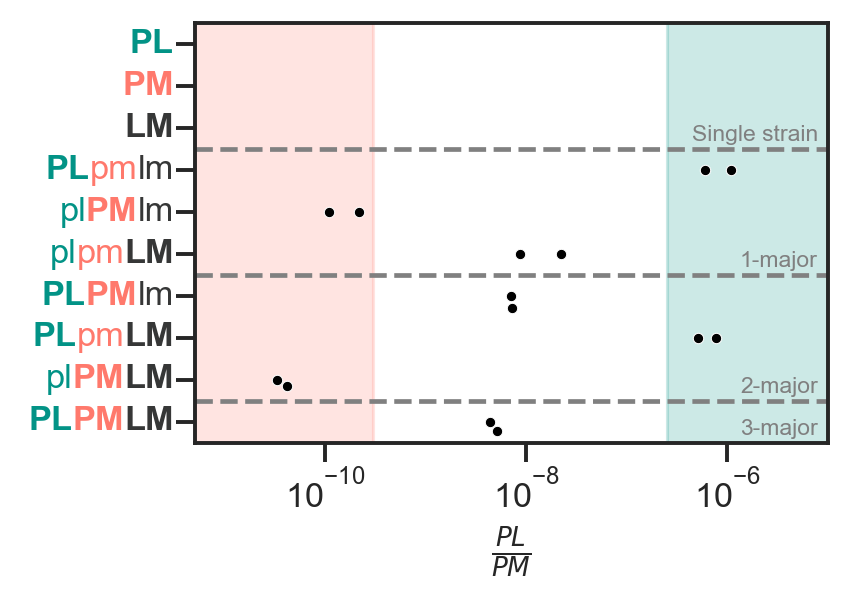

In [21]:
section_labels = {3: 'Single strain',
                  6: '1-major',
                  9: '2-major'}

dd = {k: v for k, v in d.items() if v[0] != 'M9'}

with warnings.catch_warnings():
    warnings.simplefilter('ignore', category=UserWarning)
    cp = sns.catplot(data=pn,
                 x='PL / PM',
                 y='label',
                 height=4, aspect=1.5,
                 linewidth=0.5,
                 color='k',
                 edgecolor='w',
                 kind='swarm',
                 order=[x[0] for x in dd.values()])

    cp.set(xscale='log', ylabel='', xlabel=r'$\frac{PL}{PM}$')
    
    # for i, (label, color) in enumerate(colors.items()):
    #     plt.axhspan(ymin=i - 0.5, ymax=i + 0.5,
    #                  color=color,
    #                  zorder=-1)
    
    # cp.map(plt.axvline, x=1E-10, color='grey', linestyle='--')
    # cp.map(plt.axvline, x=1E-8, color='grey', linestyle='--')
    # cp.map(plt.axvline, x=1E-6, color='grey', linestyle='--')

    plt.fill_between([1E-16, 3E-10], [-1, -1], [12, 12],
                     color='xkcd:salmon',
                     alpha=0.2,
                     zorder=-1)
    plt.fill_between([2.5E-7, 1], [-1, -1], [12, 12],
                     color='xkcd:teal',
                     alpha=0.2,
                     zorder=-1)
    
    cp.set(ylim=(i+0.5, -.5))
    
    sns.despine(right=False, top=False)
    for i, ((x, y), (label, color)) in enumerate(dd.items()):
        if i in (3, 6, 9):
            plt.axhline(i - 0.5,
                        color='grey', ls='dashed',
                        zorder=-1)
            plt.text(8E-6, i - 0.6, section_labels[i],
                     va='bottom', ha='right',
                     fontsize=11, color='grey', transform=plt.gca().transData)
        # plt.axhspan(ymin=i - 0.5, ymax=i + 0.5,
        #              color=color,
        #              zorder=-1)

    plt.xlim(5E-12, 1E-5)
    # plt.ylim(11-0.5, -0.5)
    plt.text(8E-6, 10 - 0.6, '3-major',
             va='bottom', ha='right',
             fontsize=11, color='grey', transform=plt.gca().transData)
    
    ax = plt.gca()
    apply_rich_labels(ax)
    # plt.draw()
    # plt.show()

plt.savefig('calibration_CFU_ratio.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True
           )
plt.savefig('calibration_CFU_ratio.svg',
            dpi=300, bbox_inches='tight',
            transparent=True);

## Flow cytometer (replicate 1 and 2)

In [22]:
m = pd.read_excel('flow_cytometer.xlsx')

for col in ['PL', 'PM', 'LM']:
    m[col] = [float(str(x).replace('%', '').replace(',', '.').rstrip()) for x in m[col]]
    m[col] = m[col].astype(float) / 100

In [23]:
m = m.set_index(['label', 'rep', 'events']).stack().reset_index().rename(columns={
    'level_3': 'strain',
    0: 'proportion'
})
m['strain_events'] = (m['proportion'] * m['events']) + 1

In [24]:
m = m[m['rep'].isin([1, 2])].reset_index(drop=True)

In [25]:
p = m.groupby(['label', 'rep']).apply(lambda x: x[x['strain'] == 'PL']['strain_events'].mean() / 
                                                x[x['strain'] == 'PM']['strain_events'].mean(),
                                      include_groups=False).reset_index().rename(columns={0: 'PL / PM'})

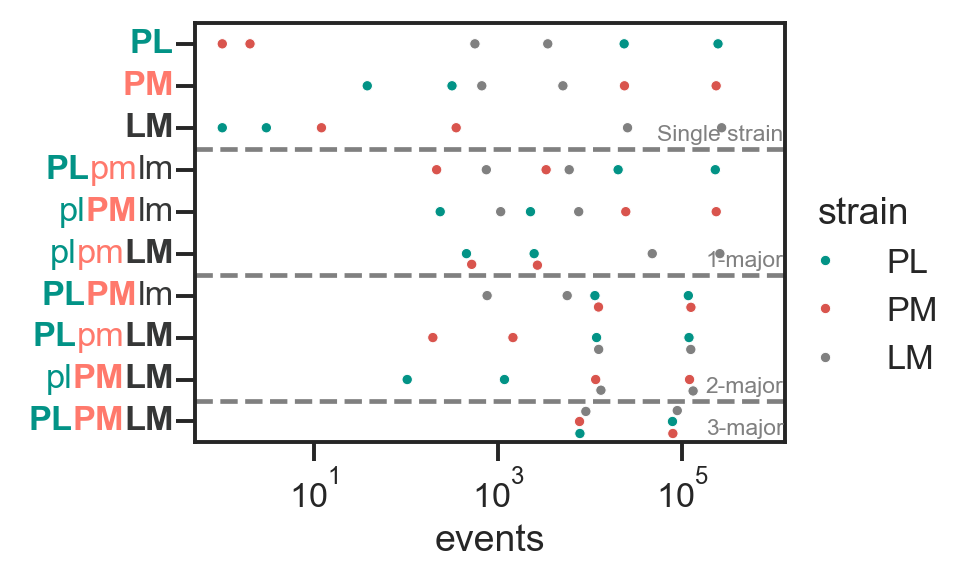

In [26]:
section_labels = {3: 'Single strain',
                  6: '1-major',
                  9: '2-major'}

with warnings.catch_warnings():
    warnings.simplefilter('ignore', category=UserWarning)
    cp = sns.catplot(data=m,
                     x='strain_events',
                     y='label',
                     hue='strain',
                     palette=['xkcd:teal',
                              'xkcd:pale red',
                              'grey'],
                     hue_order=['PL', 'PM', 'LM'],
                     height=4, aspect=1.5,
                     linewidth=0.5,
                     edgecolor='w',
                     kind='swarm',
                     order=[x[0] for x in list(d.values())[1:]])
    
    
    cp.set(xscale='log', ylabel='',
           xlim=(0.5, 1_300_000))

    sns.despine(right=False, top=False)
    
    i = 0
    for label, color in colors.items():
        if label == 'M9':
            continue
        if i in (3, 6, 9):
            plt.axhline(i - 0.5,
                        color='grey', ls='dashed',
                        zorder=-1)
            plt.text(1_250_000, i - 0.6, section_labels[i],
                     va='bottom', ha='right',
                     fontsize=11, color='grey', transform=plt.gca().transData)
        # plt.axhspan(ymin=i - 0.5, ymax=i + 0.5,
        #              color=color,
        #              zorder=-1)
        i += 1

    plt.text(1_250_000, 10 - 0.6, '3-major',
             va='bottom', ha='right',
             fontsize=11, color='grey', transform=plt.gca().transData)
    
    # cp.map(plt.axvline, x=1.5, color='grey', linestyle='--');
    cp.set(ylim=(i-0.5, -.5), xlabel='events')

    ax = plt.gca()
    apply_rich_labels(ax)
    # plt.draw()
    # plt.show()

plt.savefig('calibration_flow_events.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True
           )
plt.savefig('calibration_flow_events.svg',
            dpi=300, bbox_inches='tight',
            transparent=True);

/home/galmar/.local/share/pipx/venvs/jupyterlab/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 16.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


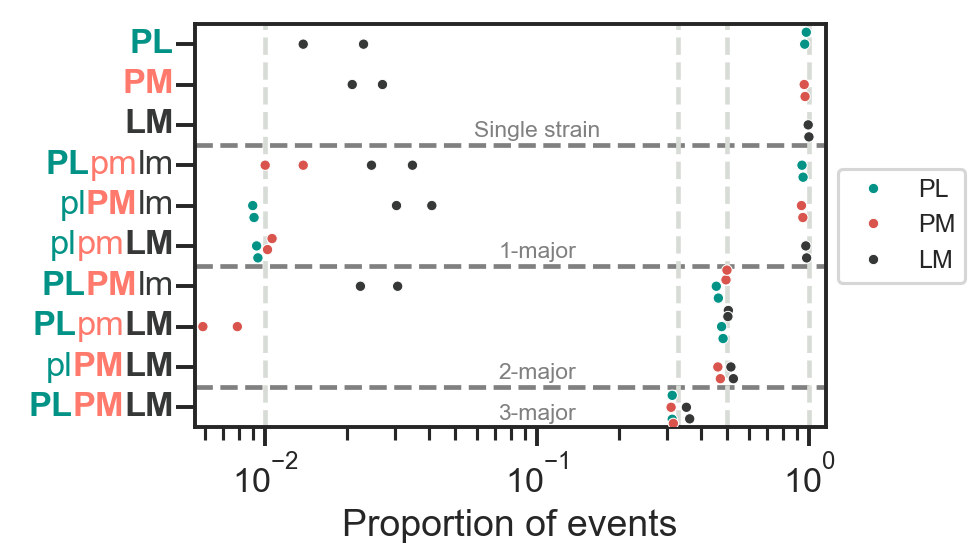

In [27]:
section_labels = {3: 'Single strain',
                  6: '1-major',
                  9: '2-major'}

with warnings.catch_warnings():
    warnings.simplefilter('ignore', category=UserWarning)
    cp = sns.catplot(data=m,
                     x='proportion',
                     y='label',
                     hue='strain',
                     palette=['xkcd:teal',
                              'xkcd:pale red',
                              'xkcd:dark grey'],
                     hue_order=['PL', 'PM', 'LM'],
                     height=4, aspect=1.5,
                     linewidth=0.5,
                     edgecolor='w',
                     kind='swarm',
                     order=[x[0] for x in list(d.values())[1:]])
    
    
    cp.set(
        xscale='log', 
        ylabel='',
           xlim=(0.0055, 1.15)
          )

    sns.despine(right=False, top=False)
    
    i = 0
    for label, color in colors.items():
        if label == 'M9':
            continue
        if i in (3, 6, 9):
            plt.axhline(i - 0.5,
                        color='grey', ls='dashed',
                        zorder=-1)
            plt.text(.10, i - 0.6, section_labels[i],
                     va='bottom', ha='center',
                     fontsize=11, color='grey', transform=plt.gca().transData)
        # plt.axhspan(ymin=i - 0.5, ymax=i + 0.5,
        #              color=color,
        #              zorder=-1)
        i += 1

    plt.text(.10, 10 - 0.6, '3-major',
             va='bottom', ha='center',
             fontsize=11, color='grey', transform=plt.gca().transData)

    for v in [0.01, 0.33, 0.5, 1]:
        cp.map(plt.axvline, x=v,
               color='xkcd:light grey', linestyle='--',
               zorder=-1)
    cp.set(ylim=(i-0.5, -.5), xlabel='Proportion of events')

    plt.legend(bbox_to_anchor=(1, 0.5),
               loc='center left',
               facecolor='white',
               fontsize=12)
    # remove seaborn legend
    cp._legend.remove()
    
    ax = plt.gca()
    apply_rich_labels(ax)
    # plt.draw()
    # plt.show()

plt.savefig('calibration_flow_proportion.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True
           )
plt.savefig('calibration_flow_proportion.svg',
            dpi=300, bbox_inches='tight',
            transparent=True);

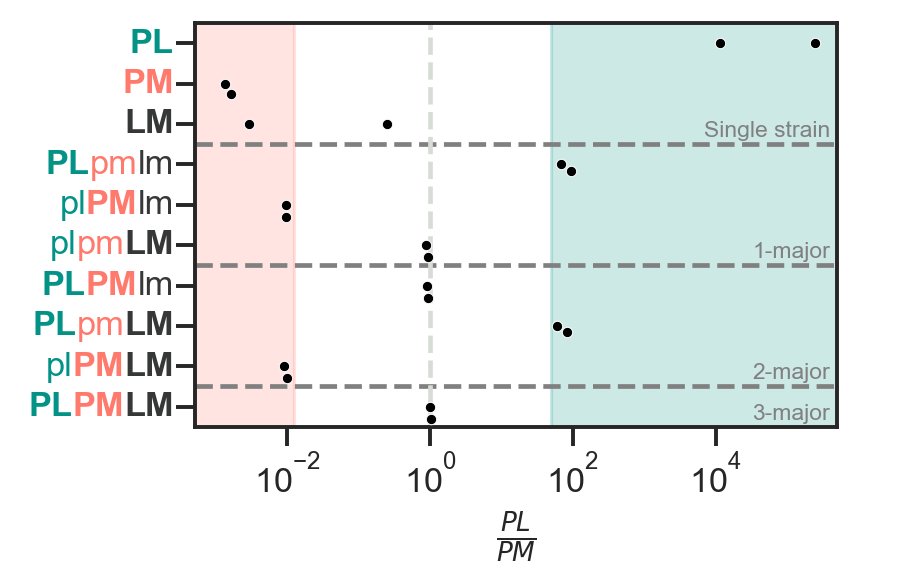

In [28]:
section_labels = {3: 'Single strain',
                  6: '1-major',
                  9: '2-major'}

with warnings.catch_warnings():
    warnings.simplefilter('ignore', category=UserWarning)
    cp = sns.catplot(data=p,
                     x='PL / PM',
                     y='label',
                     # hue='strain',
                     # palette=['xkcd:teal',
                     #          'xkcd:pale red',
                     #          'grey'],
                     # hue_order=['PL', 'PM', 'LM'],
                     height=4, aspect=1.5,
                     color='k',
                     linewidth=0.5,
                     edgecolor='w',
                     kind='swarm',
                     order=[x[0] for x in list(d.values())[1:]])
    
    
    cp.set(
           xscale='log', 
           ylabel='',
           xlim=(5E-4, 5E5)
          )

    plt.fill_between([1E-6, 0.0125], [-1, -1], [12, 12],
                     color='xkcd:salmon',
                     alpha=0.2,
                     zorder=-1)
    plt.fill_between([50, 1E6], [-1, -1], [12, 12],
                     color='xkcd:teal',
                     alpha=0.2,
                     zorder=-1)

    sns.despine(right=False, top=False)
    
    i = 0
    for label, color in colors.items():
        if label == 'M9':
            continue
        if i in (3, 6, 9):
            plt.axhline(i - 0.5,
                        color='grey', ls='dashed',
                        zorder=-1)
            plt.text(4E5, i - 0.6, section_labels[i],
                     va='bottom', ha='right',
                     fontsize=11, color='grey', transform=plt.gca().transData)
        # plt.axhspan(ymin=i - 0.5, ymax=i + 0.5,
        #              color=color,
        #              zorder=-1)
        i += 1

    plt.text(4E5, 10 - 0.6, '3-major',
             va='bottom', ha='right',
             fontsize=11, color='grey', transform=plt.gca().transData)

    for v in [1]:
        cp.map(plt.axvline, x=v,
               color='xkcd:light grey', linestyle='--',
               zorder=-1)
    cp.set(ylim=(i-0.5, -.5), xlabel=r'$\frac{PL}{PM}$')

    # plt.legend(bbox_to_anchor=(1, 0.5),
    #            loc='center left',
    #            facecolor='white',
    #            fontsize=12)
    # # remove seaborn legend
    # cp._legend.remove()
    
    ax = plt.gca()
    apply_rich_labels(ax)
    # plt.draw()
    # plt.show()

plt.savefig('calibration_flow_fraction.png',
            dpi=300,
            bbox_inches='tight',
            transparent=True
           )
plt.savefig('calibration_flow_fraction.svg',
            dpi=300, bbox_inches='tight',
            transparent=True);